In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import my_linear_regression
import importlib
importlib.reload(my_linear_regression)

from my_linear_regression import LinearRegression
lin = LinearRegression()

In [2]:
df = pd.read_json('data/imdb_ratings/titles.json').set_index('title')

df.head()

,titleType,genres,numVotes,year,averageRating
title,,,,,
The Shawshank Redemption,movie,[Drama],3185932,1994,9.3
The Dark Knight,movie,"[Action, Crime, Drama]",3165032,2008,9.1
Inception,movie,"[Action, Adventure, Sci-Fi]",2814573,2010,8.8
Game of Thrones,tvSeries,"[Action, Adventure, Drama]",2611980,2011,9.2
Breaking Bad,tvSeries,"[Crime, Drama, Thriller]",2611328,2008,9.5


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9999 entries, The Shawshank Redemption to Holiday
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   titleType      9999 non-null   object 
 1   genres         9999 non-null   object 
 2   numVotes       9999 non-null   int64  
 3   year           9999 non-null   int64  
 4   averageRating  9999 non-null   float64
dtypes: float64(1), int64(2), object(2)
memory usage: 468.7+ KB


In [4]:
df.describe()

,numVotes,year,averageRating
count,9.999000e+03,9999.00000,9999.000000
mean,1.215959e+05,2005.50495,6.849405
std,2.002060e+05,16.87822,1.046733
min,2.017100e+04,1902.00000,1.000000
25%,3.065550e+04,1999.00000,6.200000
50%,5.417300e+04,2010.00000,6.900000
75%,1.228770e+05,2018.00000,7.600000
max,3.185932e+06,2026.00000,9.800000


In [5]:
df['titleType'].unique()

array(['movie', 'tvSeries', 'tvMiniSeries', 'tvSpecial', 'tvMovie',
       'video', 'videoGame', 'short', 'tvShort'], dtype=object)

In [6]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
genres_dummies = pd.DataFrame(
    mlb.fit_transform(df['genres']),
    columns=mlb.classes_,
    index=df.index
)

df = pd.concat([df.drop(columns='genres'), genres_dummies], axis=1)

df.head()

,titleType,numVotes,year,averageRating,Action,Adventure,Animation,Biography,Comedy,Crime,...,News,Reality-TV,Romance,Sci-Fi,Short,Sport,Talk-Show,Thriller,War,Western
title,,,,,,,,,,,,,,,,,,,,,
The Shawshank Redemption,movie,3185932,1994,9.3,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
The Dark Knight,movie,3165032,2008,9.1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
Inception,movie,2814573,2010,8.8,1,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
Game of Thrones,tvSeries,2611980,2011,9.2,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Breaking Bad,tvSeries,2611328,2008,9.5,0,0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0


In [7]:
votes_per_year = df.groupby('year')['numVotes'].sum()

votes_per_year

year
1902       60904
1903       22796
1915       28289
1920       76225
1921      145632
          ...   
2022    33600306
2023    26412591
2024    21239032
2025    16714539
2026     2243376
Name: numVotes, Length: 110, dtype: int64

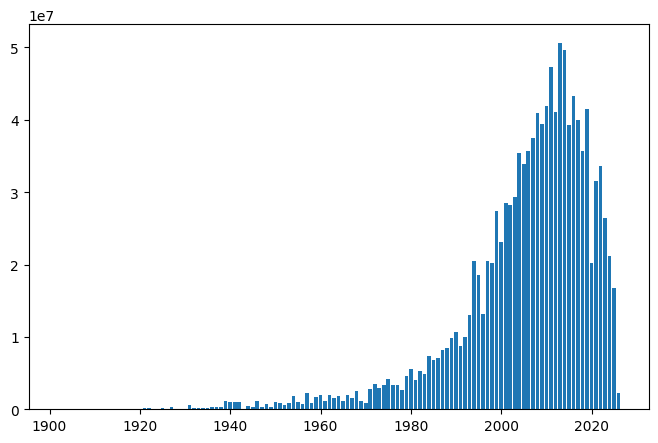

In [8]:
plt.figure(figsize=(8,5))

plt.bar(votes_per_year.index, votes_per_year.values)

plt.show()

In [9]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline

preprocessor = ColumnTransformer([
    ('num', make_pipeline(StandardScaler()), ['numVotes', 'year']),
    ('cat', make_pipeline(OneHotEncoder(handle_unknown='ignore')), ['titleType']),
], remainder='passthrough')

preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [10]:
from sklearn.model_selection import train_test_split

target = 'averageRating'

X = df.drop(target, axis=1)
y = df[target]

X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)

X_train.shape, X_val.shape, X_test.shape

((6399, 30), (1600, 30), (2000, 30))

In [11]:
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_val_preprocessed = preprocessor.transform(X_val)
X_test_preprocessed = preprocessor.transform(X_test)

In [12]:
lin.fit(X_train_preprocessed, y_train)

MSE loss at epoch 0 = 26.00132217884893
MSE loss at epoch 100 = 1.7086642567276409
MSE loss at epoch 200 = 1.3918913622808788
MSE loss at epoch 300 = 1.2271325785001526
MSE loss at epoch 400 = 1.1241227239292013
MSE loss at epoch 500 = 1.0528117023669499
MSE loss at epoch 600 = 0.9995953466756468
MSE loss at epoch 700 = 0.957761827296054
MSE loss at epoch 800 = 0.9237002716333775
MSE loss at epoch 900 = 0.8952890165584225
MSE loss at epoch 1000 = 0.8713997964063038


In [13]:
w, b = lin.w_, lin.b_

w, b

(array([ 0.30395606, -0.27462626,  1.07104048,  0.27627298,  1.05540894,
         0.17549915,  2.24476517,  0.61284966,  0.7712037 ,  0.2454697 ,
         1.18892485,  0.40509947,  0.42532227,  0.96064509,  0.68873129,
         0.66611382,  0.47699048,  1.01992039,  1.20076068,  0.4634925 ,
         0.25831505,  0.32047932,  0.39523541,  0.69451213,  0.43925109,
         0.36460218,  0.56371192,  0.40728962,  0.06818539,  0.6321811 ,
         0.35802856,  0.24293783,  1.05766355,  0.9131359 ,  0.82420572,
         0.49364858,  0.36039246,  0.75491799]),
 array([3.88136142]))

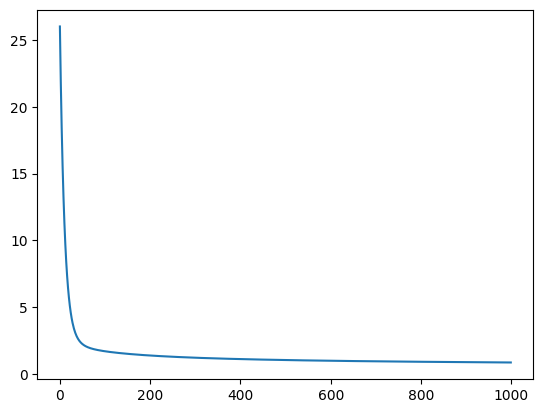

In [14]:
losses = lin.losses_

plt.plot(losses)
plt.show()

In [15]:
from sklearn.metrics import mean_squared_error

y_pred_train = lin.predict(X_train_preprocessed)
y_pred_val = lin.predict(X_val_preprocessed)

mean_squared_error(y_train, y_pred_train), mean_squared_error(y_val, y_pred_val)

(0.8711766749726845, 0.8207712234236217)

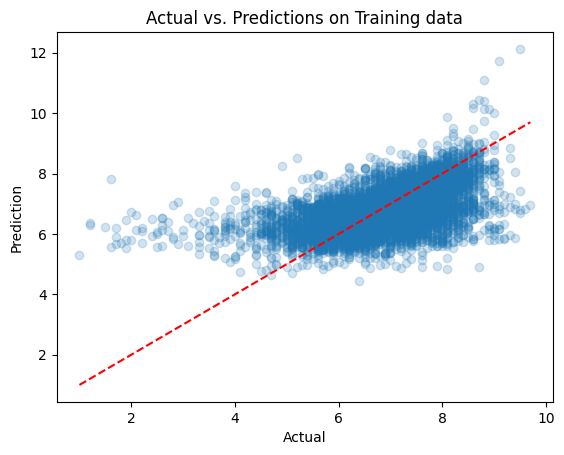

In [16]:
plt.scatter(y_train, y_pred_train, alpha=0.2)
plt.plot(
    [y_train.min(), y_train.max()],
    [y_train.min(), y_train.max()],
    'r--'
)

plt.xlabel('Actual')
plt.ylabel('Prediction')
plt.title('Actual vs. Predictions on Training data')

plt.show()

In [17]:
X_train_full_scaled = preprocessor.fit_transform(X_train_full)
X_test_scaled = preprocessor.transform(X_test)

lin.fit(X_train_full_scaled, y_train_full)

MSE loss at epoch 0 = 26.033076808540244
MSE loss at epoch 100 = 1.6954841793143043
MSE loss at epoch 200 = 1.380953688983571
MSE loss at epoch 300 = 1.21619947443251
MSE loss at epoch 400 = 1.1127536642943276
MSE loss at epoch 500 = 1.0410439353159546
MSE loss at epoch 600 = 0.9875651615874239
MSE loss at epoch 700 = 0.9455997483131201
MSE loss at epoch 800 = 0.9115073169226986
MSE loss at epoch 900 = 0.8831363124744845
MSE loss at epoch 1000 = 0.8593329362143961


In [18]:
y_pred = lin.predict(X_test_scaled)

mean_squared_error(y_test, y_pred)

0.8736066732210914